# 03 — Exploratory analysis of player behaviour

Explore the cleaned bwin casino cohort before choosing feature and prediction windows.
Inputs are the two local cleaned CSVs; only figures are written to `reports/figures/`.
All players, outliers, zero-value days, and signed accounting corrections are retained.
No churn labels or models are created. Player summaries are descriptive full-period
aggregates held in memory, **not features available at a historical prediction date**.

**Source:** `data/raw/Codebook_for_Virtual_Casino_Gambling.pdf`, variable definitions
and Appendices 1–2. Amounts are euros. Gender is 0 = female, 1 = male.
The source describes a February 2005 registration cohort selected for casino activity,
so these results do not describe all new accounts or present-day customers.
The observed daily date endpoints, rather than the inconsistent study-end wording in
the codebook introduction, determine the coverage used here.

Interpretations below were populated from successful execution of these local inputs.
If inputs change, update the interpretations alongside the tables and charts.

## 1. Load and revalidate the cleaned datasets
Dates are parsed explicitly. Check expected schemas, shapes, player coverage, missingness,
finite amounts, nonnegative Stake/Bets, unique player-day keys, and every date range.
Hash inputs before and after analysis to verify read-only use.

In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

project_root = next((p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'data/processed/demographics_clean.csv').is_file()
    and (p / 'notebooks').is_dir()), None)
if project_root is None:
    raise FileNotFoundError('Run from the repository root or notebooks directory.')
input_paths = [project_root / 'data/processed' / name for name in
               ['demographics_clean.csv', 'daily_activity_clean.csv']]
input_hashes = {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in input_paths}
FIGURE_DIR = project_root / 'reports/figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 20)
pd.set_option('display.precision', 3)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 14, 'axes.labelsize': 11, 'font.size': 10,
    'axes.facecolor': '#f8fafc', 'figure.facecolor': 'white'})
BLUE, TEAL = '#2563a6', '#16857b'
saved_figures = []
section_notes = {}
def save_show(fig, name):
    fig.savefig(FIGURE_DIR / name, bbox_inches='tight')
    saved_figures.append(name)
    plt.show()
    plt.close(fig)

demographics = pd.read_csv(input_paths[0],
    dtype={c: 'int64' for c in ['UserID', 'Country', 'Language', 'Gender']})
daily = pd.read_csv(input_paths[1], dtype={'UserID': 'int64', 'Bets': 'int64'},
                    float_precision='round_trip')
assert demographics.columns.tolist() == ['UserID', 'Country', 'Language', 'Gender',
                                         'RegDate', 'Fstcadate', 'Fstpdate']
assert daily.columns.tolist() == ['UserID', 'Date', 'Stake', 'Winnings', 'Bets']
for col in ['RegDate', 'Fstcadate', 'Fstpdate']:
    demographics[col] = pd.to_datetime(demographics[col], format='%Y-%m-%d', errors='raise')
daily['Date'] = pd.to_datetime(daily['Date'], format='%Y-%m-%d', errors='raise')
assert demographics.shape == (4222, 7)
assert daily.shape == (98991, 5)
assert demographics.UserID.is_unique
assert not daily.duplicated(['UserID', 'Date']).any()
assert set(demographics.UserID) == set(daily.UserID)
assert daily.UserID.nunique() == 4222
assert not demographics.isna().any().any() and not daily.isna().any().any()
assert np.isfinite(daily[['Stake', 'Winnings', 'Bets']]).all().all()
assert daily[['Stake', 'Bets']].ge(0).all().all()
study_start, study_end = daily.Date.min(), daily.Date.max()
assert study_start == pd.Timestamp('2005-02-01')
assert study_end == pd.Timestamp('2007-02-28')
display(pd.DataFrame([{'dataset': name, 'rows': len(frame), 'columns': frame.shape[1],
    'unique_players': frame.UserID.nunique()} for name, frame in
    [('Demographics', demographics), ('Daily activity', daily)]]))
date_ranges = pd.DataFrame([{'dataset': name, 'field': col,
    'first': frame[col].min(), 'last': frame[col].max()} for name, frame, cols in
    [('Demographics', demographics, ['RegDate', 'Fstcadate', 'Fstpdate']),
     ('Daily activity', daily, ['Date'])] for col in cols])
display(date_ranges)
display(pd.Series({'zero_bet_days': int(daily.Bets.eq(0).sum()),
    'zero_stake_days': int(daily.Stake.eq(0).sum()),
    'negative_winnings_days': int(daily.Winnings.lt(0).sum())}, name='days').to_frame())
section_notes['validation'] = f"""**Interpretation.** Both expected shapes, all 4,222 players, and unique
player-date keys are confirmed. Daily coverage is {study_start.date()} to {study_end.date()}.
There are {daily.Bets.eq(0).sum():,} zero-bet days and {daily.Winnings.lt(0).sum():,}
negative-Winnings days after cleaning. Recorded days can include accounting entries;
they are not necessarily days with a positive bet. All are retained."""

,dataset,rows,columns,unique_players
0,Demographics,4222,7,4222
1,Daily activity,98991,5,4222


,dataset,field,first,last
0,Demographics,RegDate,2005-02-01,2005-02-28
1,Demographics,Fstcadate,2005-02-01,2007-01-30
2,Demographics,Fstpdate,2005-02-01,2007-01-25
3,Daily activity,Date,2005-02-01,2007-02-28


,days
zero_bet_days,42
zero_stake_days,4896
negative_winnings_days,69


**Interpretation.** Both expected shapes, all 4,222 players, and unique
player-date keys are confirmed. Daily coverage is 2005-02-01 to 2007-02-28.
There are 42 zero-bet days and 69
negative-Winnings days after cleaning. Recorded days can include accounting entries;
they are not necessarily days with a positive bet. All are retained.

## 2. Player-level descriptive summaries
An **active day** in the main analysis is a distinct date with a canonical activity record.
Also retain positive-bet-day counts for sensitivity analysis. Calendar activity span is
`last observed date - first observed date` (exclusive difference, zero for one-day play).
Tenure is elapsed days from first pay-in to **2007-02-28**, not days actually played;
also report pay-in to last observed activity. Average stake per bet is total Stake divided
by total Bets; zero denominators produce missing ratios, never fabricated zeros.
Net loss is Stake minus Winnings: negative net loss means net winnings.

In [2]:
players = daily.groupby('UserID').agg(
    active_days=('Date', 'nunique'), total_bets=('Bets', 'sum'),
    total_stake=('Stake', 'sum'), total_winnings=('Winnings', 'sum'),
    first_activity=('Date', 'min'), last_activity=('Date', 'max'),
    positive_bet_days=('Bets', lambda x: x.gt(0).sum())).reset_index()
players = players.merge(demographics, on='UserID', how='left', validate='one_to_one')
players['net_loss'] = players.total_stake - players.total_winnings
players['avg_bets_per_active_day'] = players.total_bets / players.active_days
players['avg_stake_per_bet'] = players.total_stake / players.total_bets.where(players.total_bets.gt(0))
players['activity_span_days'] = (players.last_activity - players.first_activity).dt.days
players['tenure_days_at_study_end'] = (study_end - players.Fstpdate).dt.days
players['pay_in_to_last_activity_days'] = (players.last_activity - players.Fstpdate).dt.days
assert len(players) == 4222 and players.UserID.is_unique
assert players.active_days.sum() == len(daily)
assert players.total_bets.sum() == daily.Bets.sum()
for player_col, daily_col in [('total_stake', 'Stake'), ('total_winnings', 'Winnings')]:
    assert np.isclose(players[player_col].sum(), daily[daily_col].sum(), rtol=0, atol=1e-6)
display(players.head())
display(pd.Series({'players_without_positive_bets': int(players.total_bets.eq(0).sum()),
    'observed_first_activity_before_pay_in': int(players.first_activity.lt(players.Fstpdate).sum()),
    'first_observed_date_differs_from_Fstcadate': int(players.first_activity.ne(players.Fstcadate).sum()),
    'players_with_recorded_nonbet_days': int(players.active_days.ne(players.positive_bet_days).sum())},
    name='players').to_frame())
summary_columns = ['active_days', 'positive_bet_days', 'total_bets', 'total_stake',
    'total_winnings', 'net_loss', 'avg_bets_per_active_day', 'avg_stake_per_bet',
    'activity_span_days', 'tenure_days_at_study_end', 'pay_in_to_last_activity_days']
robust_summary = players[summary_columns].quantile([.25, .5, .75, .9, .95, .99, 1]).T
robust_summary.columns = ['Q1', 'Median', 'Q3', 'P90', 'P95', 'P99', 'Maximum']
robust_summary.insert(0, 'N', players[summary_columns].count())
robust_summary.insert(1, 'Mean', players[summary_columns].mean())
robust_summary.insert(2, 'Minimum', players[summary_columns].min())
display(robust_summary)
section_notes['players'] = f"""**Interpretation.** The typical player records
{players.active_days.median():.0f} active days (middle half:
{players.active_days.quantile(.25):.0f}–{players.active_days.quantile(.75):.0f}),
{players.total_bets.median():,.0f} bets, and {players.avg_bets_per_active_day.median():,.1f}
bets per recorded active day. Median first-to-last observed activity span is
{players.activity_span_days.median():.0f} days; median pay-in tenure at the study end is
{players.tenure_days_at_study_end.median():.0f} days. Long account tenure does not imply frequent play.
{players.first_activity.ne(players.Fstcadate).sum():,} players have an observed first date
different from the demographic first-casino date; the observed dates define our spans.
{players.first_activity.lt(players.Fstpdate).sum():,} players have observed activity before pay-in.
These full-period summaries must be rebuilt using only past data for any future model."""

,UserID,active_days,total_bets,total_stake,total_winnings,first_activity,last_activity,positive_bet_days,Country,Language,Gender,RegDate,Fstcadate,Fstpdate,net_loss,avg_bets_per_active_day,avg_stake_per_bet,activity_span_days,tenure_days_at_study_end,pay_in_to_last_activity_days
0,1324364,5,1430,2180.50,2078.000,2006-08-26,2007-02-14,5,276,2,1,2005-02-01,2006-08-26,2005-02-03,102.500,286.000,1.525,172,755,741
1,1324369,56,1738,9521.00,9206.000,2005-03-01,2007-01-06,56,792,7,1,2005-02-01,2005-03-01,2005-02-01,315.000,31.036,5.478,676,757,704
2,1324377,5,7,59.00,28.000,2005-04-04,2006-11-04,5,208,11,1,2005-02-01,2005-04-04,2005-02-01,31.000,1.400,8.429,579,757,641
3,1324383,4,168,5529.53,4892.500,2005-06-05,2005-06-12,4,578,10,1,2005-02-01,2005-06-05,2005-02-03,637.030,42.000,32.914,7,755,129
4,1324386,31,7132,68104.22,67187.512,2005-02-10,2007-01-22,31,756,1,1,2005-02-01,2005-02-10,2005-02-09,916.708,230.065,9.549,711,749,712


,players
players_without_positive_bets,0
observed_first_activity_before_pay_in,0
first_observed_date_differs_from_Fstcadate,116
players_with_recorded_nonbet_days,40


,N,Mean,Minimum,Q1,Median,Q3,P90,P95,P99,Maximum
active_days,4222,23.446,4.000,6.000,11.000,24.000,54.000,86.000,197.950,5.240e+02
positive_bet_days,4222,23.437,4.000,6.000,11.000,24.000,54.000,86.000,197.950,5.240e+02
total_bets,4222,3515.048,4.000,139.000,532.000,1984.000,6994.900,15066.700,53042.580,2.440e+05
total_stake,4222,27171.583,0.120,578.125,2603.340,12820.270,54196.587,120254.127,437980.518,3.439e+06
total_winnings,4222,26331.873,0.000,523.355,2429.785,12220.413,52029.836,117983.989,424536.780,3.395e+06
net_loss,4222,839.710,-16306.202,27.970,117.250,473.687,1924.900,3723.450,14872.548,8.244e+04
avg_bets_per_active_day,4222,115.951,1.000,13.000,48.911,129.148,294.813,465.657,939.282,2.342e+03
avg_stake_per_bet,4222,34.761,0.004,1.479,4.158,13.657,51.102,123.723,637.172,7.920e+03
activity_span_days,4222,298.207,3.000,69.000,260.000,499.000,660.000,711.950,738.000,7.560e+02
tenure_days_at_study_end,4222,707.898,34.000,730.000,737.000,747.000,753.000,755.000,757.000,7.570e+02


**Interpretation.** The typical player records
11 active days (middle half:
6–24),
532 bets, and 48.9
bets per recorded active day. Median first-to-last observed activity span is
260 days; median pay-in tenure at the study end is
737 days. Long account tenure does not imply frequent play.
116 players have an observed first date
different from the demographic first-casino date; the observed dates define our spans.
0 players have observed activity before pay-in.
These full-period summaries must be rebuilt using only past data for any future model.

## 3. Activity and monetary distributions
Use logarithmically spaced bins and log x axes for positive variables, while drawing
zero counts separately when present. Signed amounts use a symmetric log axis and
bins around zero, preserving both net winners and net losers. No values are clipped
or excluded. A mean is included only as a skew diagnostic beside the robust summaries.
Average stake per bet weights a player's bets through the ratio of totals.

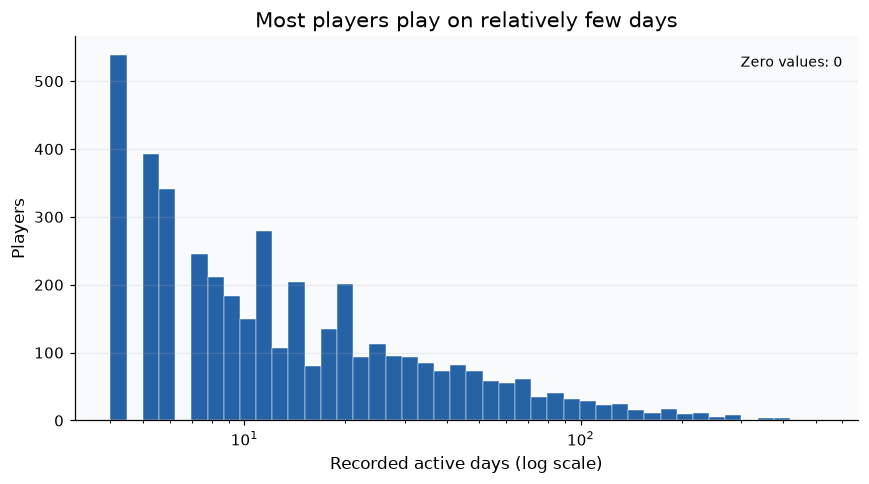

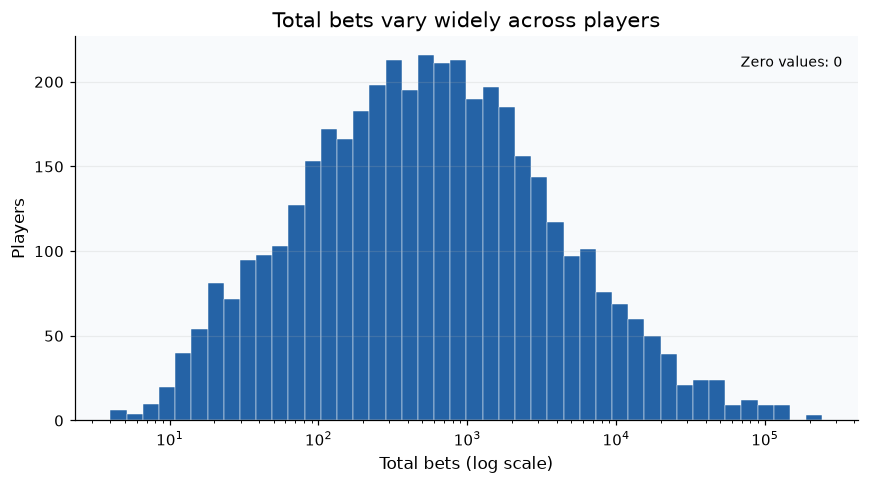

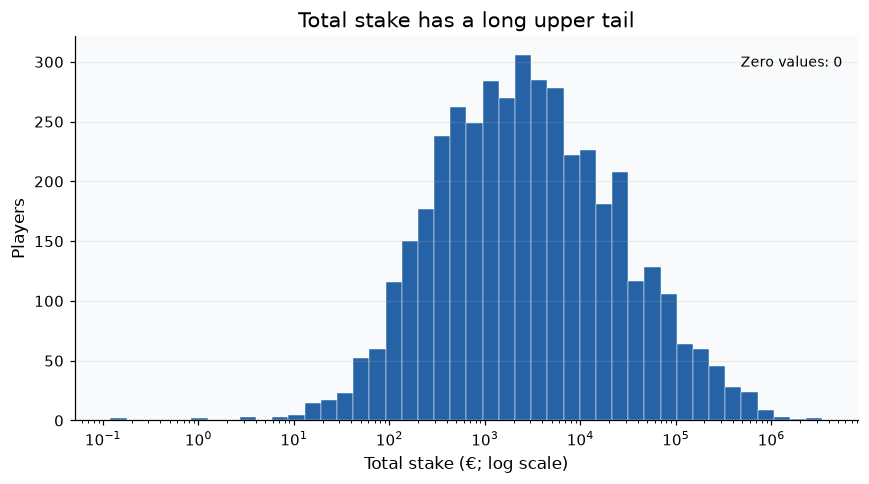

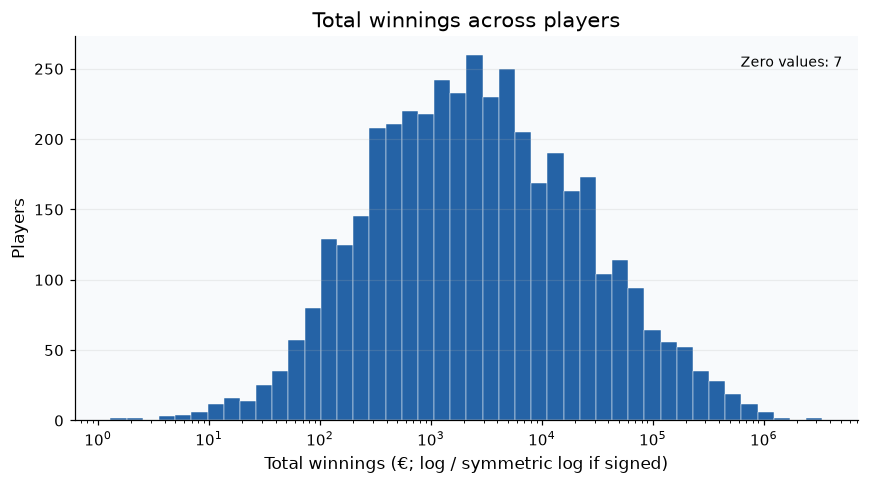

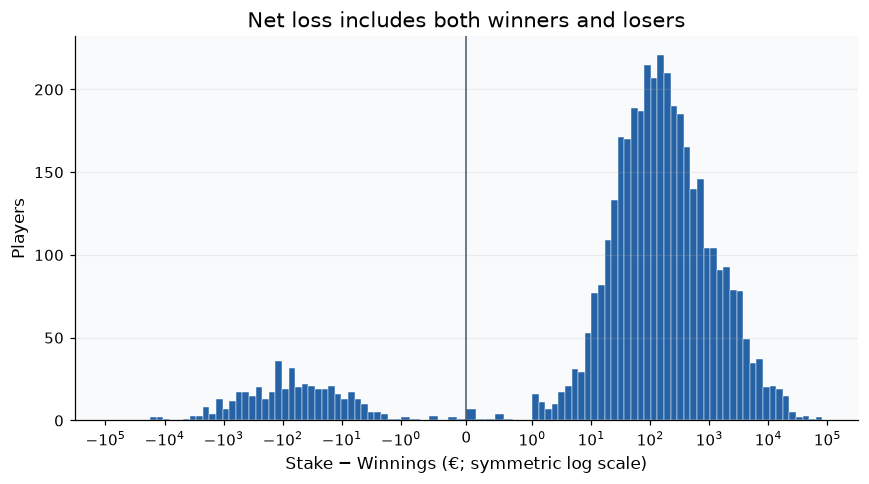

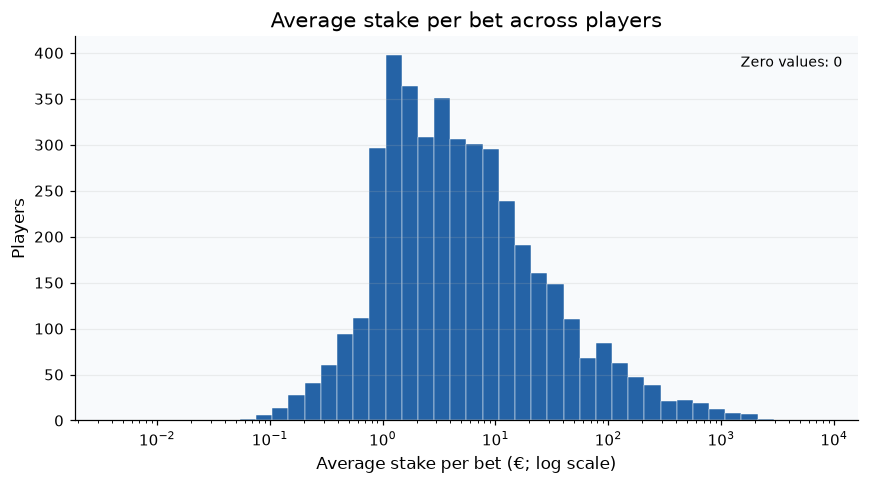

In [3]:
def distribution(values, title, xlabel, filename, signed=False):
    values = values.dropna()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    if signed or values.lt(0).any():
        bound = max(abs(values.min()), abs(values.max()), 1)
        edges = np.unique(np.r_[-np.geomspace(1, bound + 1, 45)[::-1],
                                np.linspace(-1, 1, 15), np.geomspace(1, bound + 1, 45)])
        ax.hist(values, bins=edges, color=BLUE, edgecolor='white', linewidth=.3)
        ax.set_xscale('symlog', linthresh=1)
        ax.axvline(0, color='#475569', linewidth=1)
    else:
        positive = values[values.gt(0)]
        if len(positive):
            edges = np.geomspace(positive.min(), max(positive.max(), positive.min()*1.01), 45)
            ax.hist(positive, bins=edges, color=BLUE, edgecolor='white', linewidth=.3)
            ax.set_xscale('log')
        ax.text(.98, .95, f'Zero values: {values.eq(0).sum():,}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9)
    ax.set(title=title, xlabel=xlabel, ylabel='Players')
    ax.grid(axis='y', alpha=.2)
    fig.tight_layout()
    save_show(fig, filename)

for column, title, xlabel, filename, signed in [
    ('active_days', 'Most players play on relatively few days', 'Recorded active days (log scale)', 'active_days_distribution.png', False),
    ('total_bets', 'Total bets vary widely across players', 'Total bets (log scale)', 'total_bets_distribution.png', False),
    ('total_stake', 'Total stake has a long upper tail', 'Total stake (€; log scale)', 'stake_distribution.png', False),
    ('total_winnings', 'Total winnings across players', 'Total winnings (€; log / symmetric log if signed)', 'winnings_distribution.png', False),
    ('net_loss', 'Net loss includes both winners and losers', 'Stake − Winnings (€; symmetric log scale)', 'net_loss_distribution.png', True),
    ('avg_stake_per_bet', 'Average stake per bet across players', 'Average stake per bet (€; log scale)', 'average_stake_per_bet_distribution.png', False)]:
    distribution(players[column], title, xlabel, filename, signed)

top_n = int(np.ceil(.01 * len(players)))
top_stake_share = players.total_stake.nlargest(top_n).sum() / players.total_stake.sum() * 100
section_notes['distributions'] = f"""**Interpretation.** Player total stake has median
€{players.total_stake.median():,.2f}, mean €{players.total_stake.mean():,.2f},
P95 €{players.total_stake.quantile(.95):,.2f}, P99 €{players.total_stake.quantile(.99):,.2f},
and maximum €{players.total_stake.max():,.2f}. The top {top_n} players (approximately 1%)
contribute {top_stake_share:.1f}% of total stake, showing why means alone are inadequate.
Median total winnings are €{players.total_winnings.median():,.2f}; median net loss is
€{players.net_loss.median():,.2f}. {players.net_loss.lt(0).sum():,} players
({players.net_loss.lt(0).mean()*100:.1f}%) have negative net loss (net winners).
Median average stake per bet is €{players.avg_stake_per_bet.median():,.2f}.
Stake is cumulative turnover, not unique deposits or disposable income; repeated betting
can recycle winnings. The entire upper tail and signed corrections remain in the analysis."""

**Interpretation.** Player total stake has median
€2,603.34, mean €27,171.58,
P95 €120,254.13, P99 €437,980.52,
and maximum €3,439,061.61. The top 43 players (approximately 1%)
contribute 31.0% of total stake, showing why means alone are inadequate.
Median total winnings are €2,429.78; median net loss is
€117.25. 458 players
(10.8%) have negative net loss (net winners).
Median average stake per bet is €4.16.
Stake is cumulative turnover, not unique deposits or disposable income; repeated betting
can recycle winnings. The entire upper tail and signed corrections remain in the analysis.

## 4. Monthly activity and stake versus activity days
Count distinct players within each calendar month; the same player can appear in many
months. Include every month in the observed range. Monetary and bet totals retain all
records. This is one registration cohort, not a platform-wide acquisition time series.
The scatter uses log axes and transparency to show all players without trimming.

,active_players,total_stake,total_bets,recorded_days
month,,,,
2005-02,1839,7.095e+06,1202453,7115
2005-03,1847,1.167e+07,1380226,9828
2005-04,1314,6.318e+06,777464,6393
2005-05,1044,5.977e+06,618671,4831
2005-06,876,4.316e+06,537716,4047
2005-07,830,4.986e+06,567577,3629
2005-08,884,5.421e+06,571119,3814
2005-09,1043,5.766e+06,639635,4426
2005-10,926,5.233e+06,545320,4065


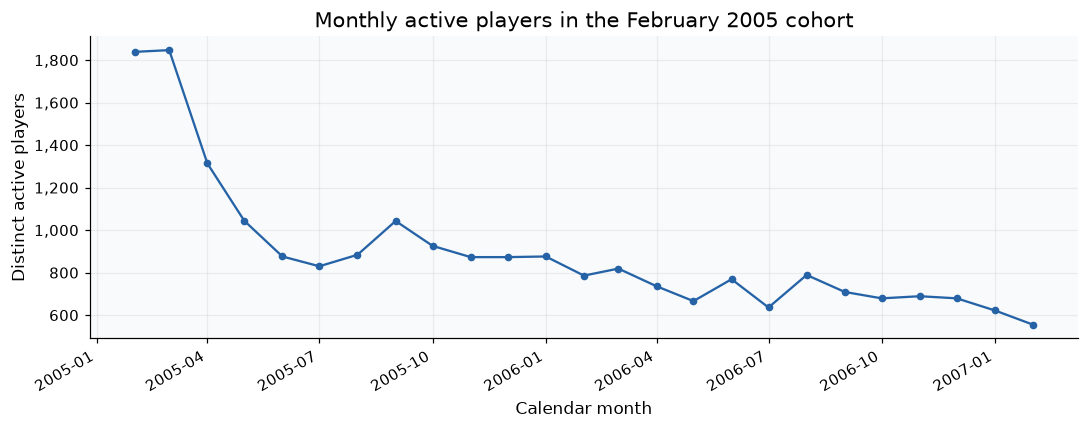

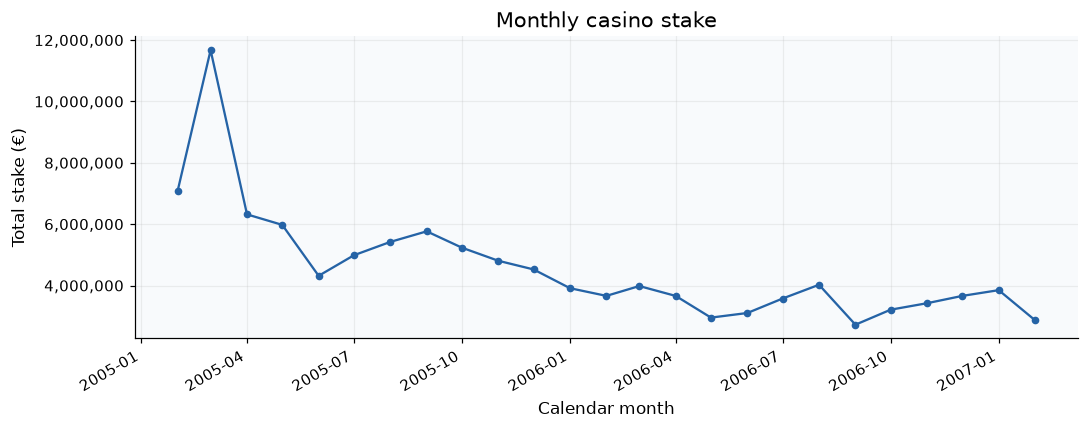

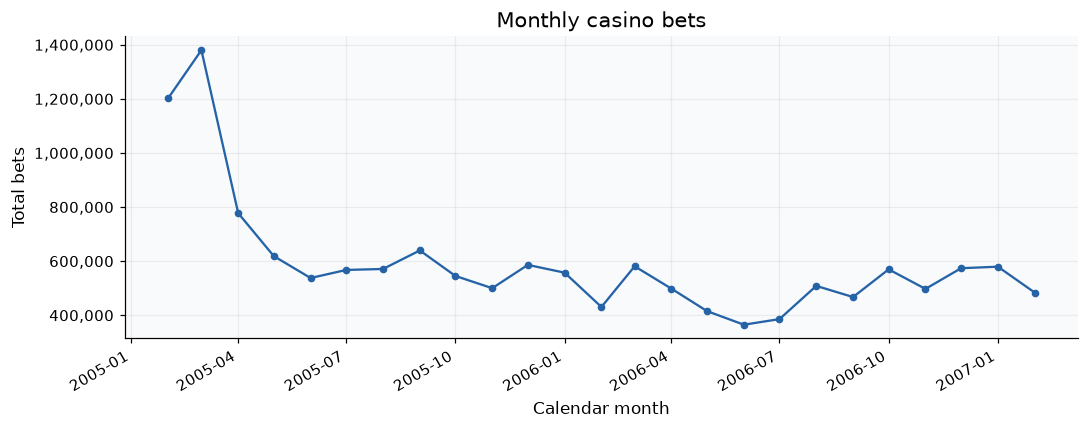

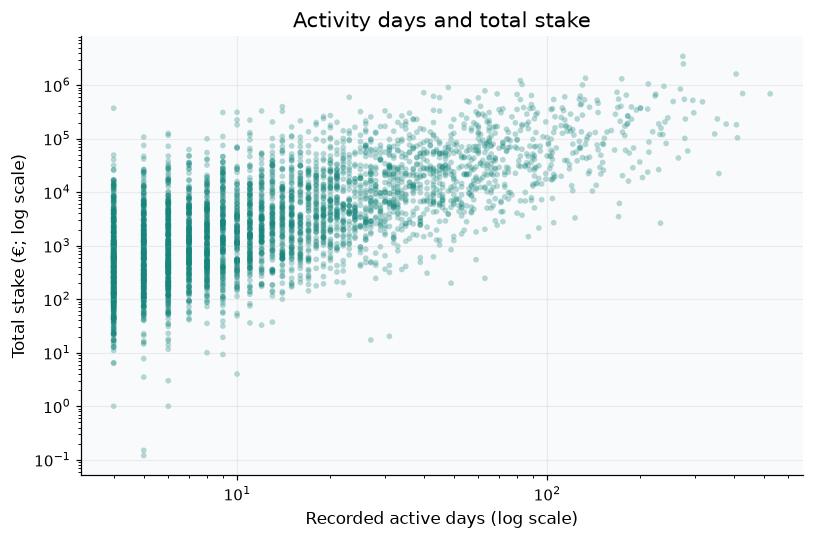

In [4]:
month_index = pd.period_range(study_start, study_end, freq='M')
monthly = daily.assign(month=daily.Date.dt.to_period('M')).groupby('month').agg(
    active_players=('UserID', 'nunique'), total_stake=('Stake', 'sum'),
    total_bets=('Bets', 'sum'), recorded_days=('Date', 'size')).reindex(month_index, fill_value=0)
monthly.index.name = 'month'
display(monthly)
for column, title, ylabel, filename in [
    ('active_players', 'Monthly active players in the February 2005 cohort', 'Distinct active players', 'monthly_active_players.png'),
    ('total_stake', 'Monthly casino stake', 'Total stake (€)', 'monthly_total_stake.png'),
    ('total_bets', 'Monthly casino bets', 'Total bets', 'monthly_total_bets.png')]:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(monthly.index.to_timestamp(), monthly[column], color=BLUE, marker='o', markersize=4)
    ax.set(title=title, xlabel='Calendar month', ylabel=ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f}'))
    ax.grid(alpha=.2)
    fig.autofmt_xdate()
    fig.tight_layout()
    save_show(fig, filename)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(players.active_days, players.total_stake, s=14, alpha=.3, color=TEAL,
           edgecolors='none', rasterized=True)
assert players.total_stake.gt(0).all(), 'Adapt plot to include zero stakes if inputs change.'
ax.set_xscale('log'); ax.set_yscale('log')
ax.set(title='Activity days and total stake', xlabel='Recorded active days (log scale)',
       ylabel='Total stake (€; log scale)')
ax.grid(alpha=.2)
fig.tight_layout()
save_show(fig, 'active_days_vs_total_stake.png')
spearman = players[['active_days', 'total_stake']].rank().corr().iloc[0, 1]
section_notes['monthly'] = f"""**Interpretation.** Monthly active players change from
{monthly.active_players.iloc[0]:,} in {monthly.index[0]} to
{monthly.active_players.iloc[-1]:,} in {monthly.index[-1]}
({(monthly.active_players.iloc[-1]/monthly.active_players.iloc[0]-1)*100:.1f}%).
The highest monthly count is {monthly.active_players.max():,} in {monthly.active_players.idxmax()}.
Monthly stake changes from €{monthly.total_stake.iloc[0]:,.0f} to
€{monthly.total_stake.iloc[-1]:,.0f}; its peak occurs in {monthly.total_stake.idxmax()}.
Monthly bets change from {monthly.total_bets.iloc[0]:,} to {monthly.total_bets.iloc[-1]:,}.
These changes mix participation, delayed casino activation, and spending intensity within
a fixed registration cohort; they cannot establish seasonality or business growth.
Active days and total stake have rank correlation {spearman:.3f}; cumulative stake is
partly mechanically related to the number of activity days. This is association, not causation."""

**Interpretation.** Monthly active players change from
1,839 in 2005-02 to
555 in 2007-02
(-69.8%).
The highest monthly count is 1,847 in 2005-03.
Monthly stake changes from €7,094,805 to
€2,865,391; its peak occurs in 2005-03.
Monthly bets change from 1,202,453 to 483,975.
These changes mix participation, delayed casino activation, and spending intensity within
a fixed registration cohort; they cannot establish seasonality or business growth.
Active days and total stake have rank correlation 0.666; cumulative stake is
partly mechanically related to the number of activity days. This is association, not causation.

## 5. Country, language, and gender
Mappings below are transcribed from the **local official codebook**: Appendix 1 (Country),
Appendix 2 (Language), and the Gender variable table. Country mappings cover all 46
observed codes and retain historical names as printed (including Serbia and Montenegro).
Language mappings include all 22 documented values. Original numeric columns remain
untouched; readable labels are additional columns. Unknown values would be named
explicitly and fail the coverage check instead of being silently guessed.

Tables distinguish representation (player count/share), frequency (median active days),
and volume (total stake/bets). Group totals are sensitive to group size and high spenders.
Show every country; avoid collapsing the tail or ranking small groups as reliable effects.

Country


,,players,median_active_days,total_active_days,total_bets,total_stake,median_player_stake,player_percent
Country,Country_name,,,,,,,
276,Germany,784,11.0,17608,2115055,1.906e+07,3388.750,18.569
300,Greece,482,11.0,11496,2568883,1.836e+07,5290.000,11.416
40,Austria,468,12.0,13418,1510556,2.147e+07,3472.625,11.085
724,Spain,425,10.0,10299,1338465,1.581e+07,3088.930,10.066
250,France,373,10.0,9086,1603793,6.899e+06,1479.000,8.835
208,Denmark,355,11.0,7862,1125092,6.232e+06,1723.750,8.408
380,Italy,318,12.0,9393,1683042,8.677e+06,3018.413,7.532
792,Turkey,317,9.0,5293,907353,3.021e+06,1447.250,7.508
616,Poland,223,11.0,4690,628043,3.125e+06,815.750,5.282


Language


,,players,median_active_days,total_active_days,total_bets,total_stake,median_player_stake,player_percent
Language,Language_name,,,,,,,
2,German,1419,11.0,35169,4259735,4.643e+07,3384.300,33.610
8,Greek,488,11.0,11650,2577003,1.841e+07,5101.000,11.559
6,French,398,10.0,9538,1682163,7.267e+06,1477.250,9.427
4,Spanish,395,10.0,9435,1244197,1.393e+07,3181.000,9.356
11,Danish,347,11.0,7807,1119014,6.230e+06,1793.000,8.219
7,Turkish,318,9.0,5364,925655,3.169e+06,1509.000,7.532
3,Italian,313,12.0,9243,1633432,8.401e+06,3019.870,7.414
9,Polish,216,10.0,4296,480882,2.481e+06,775.605,5.116
1,English,169,9.0,3258,450567,4.065e+06,2543.000,4.003


Gender


,,players,median_active_days,total_active_days,total_bets,total_stake,median_player_stake,player_percent
Gender,Gender_name,,,,,,,
1,Male,3924,11.0,91984,13608672,1.083e+08,2545.365,92.942
0,Female,298,12.0,7007,1231860,6.394e+06,3434.000,7.058


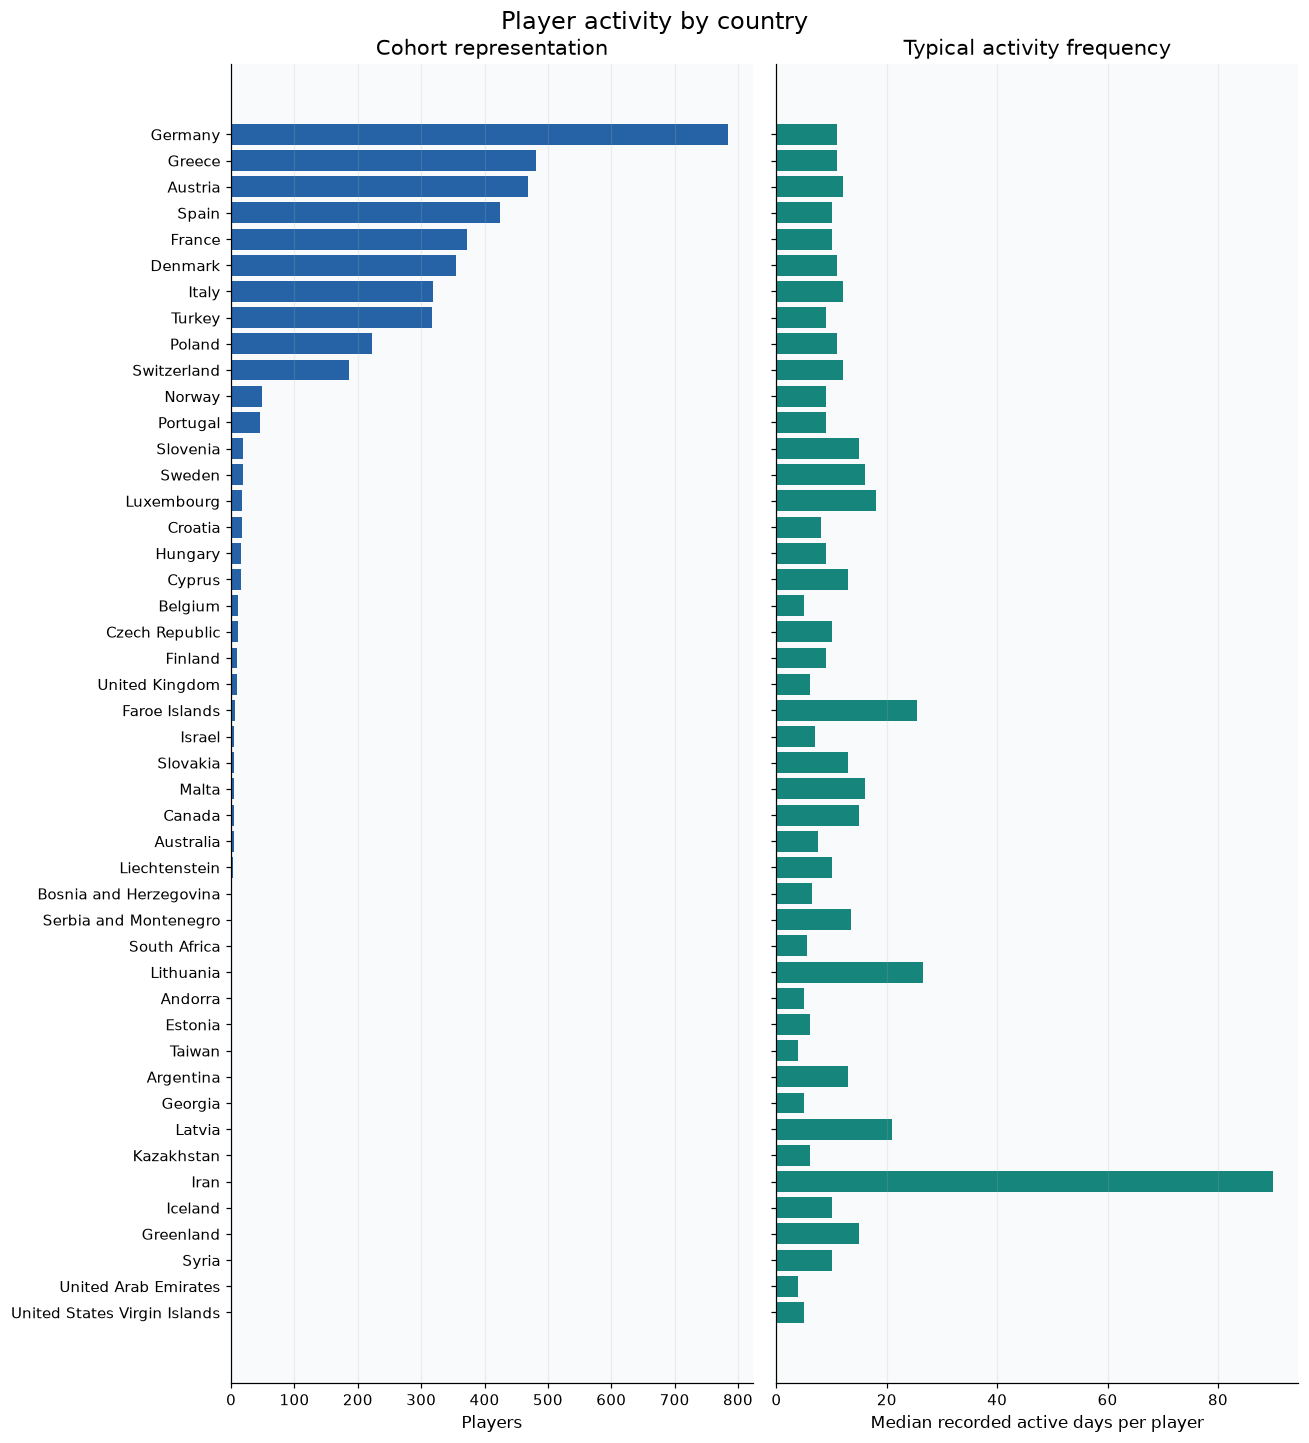

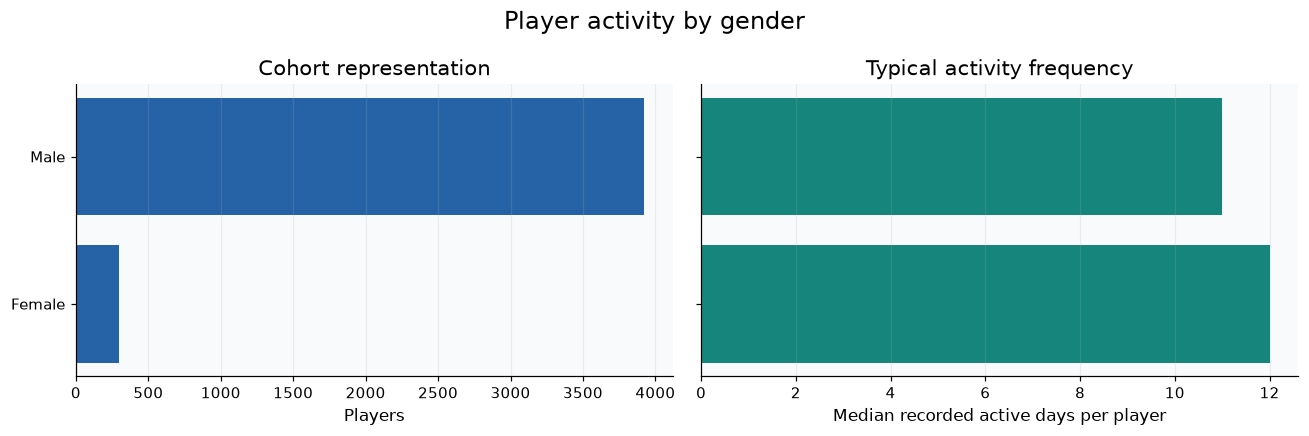

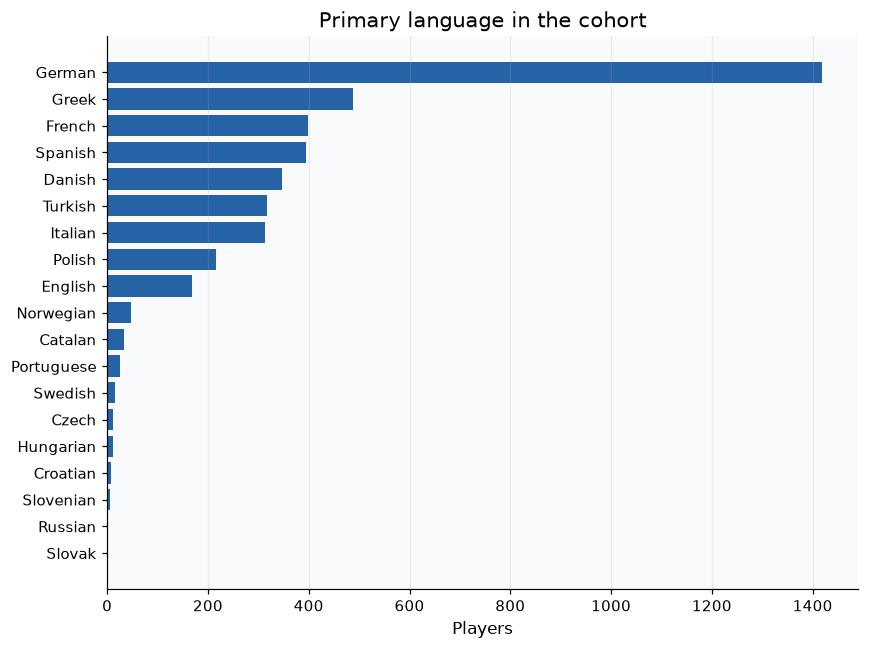

In [5]:
COUNTRY_MAP = {
    20: 'Andorra', 32: 'Argentina', 36: 'Australia', 40: 'Austria', 56: 'Belgium',
    70: 'Bosnia and Herzegovina', 124: 'Canada', 158: 'Taiwan', 191: 'Croatia',
    196: 'Cyprus', 203: 'Czech Republic', 208: 'Denmark', 233: 'Estonia',
    234: 'Faroe Islands', 246: 'Finland', 250: 'France', 268: 'Georgia',
    276: 'Germany', 300: 'Greece', 304: 'Greenland', 348: 'Hungary', 352: 'Iceland',
    364: 'Iran', 376: 'Israel', 380: 'Italy', 398: 'Kazakhstan', 428: 'Latvia',
    438: 'Liechtenstein', 440: 'Lithuania', 442: 'Luxembourg', 470: 'Malta',
    578: 'Norway', 616: 'Poland', 620: 'Portugal', 703: 'Slovakia', 705: 'Slovenia',
    710: 'South Africa', 724: 'Spain', 752: 'Sweden', 756: 'Switzerland', 760: 'Syria',
    784: 'United Arab Emirates', 792: 'Turkey', 826: 'United Kingdom',
    850: 'United States Virgin Islands', 891: 'Serbia and Montenegro'}
LANGUAGE_MAP = dict(enumerate(['English', 'German', 'Italian', 'Spanish', 'Swedish',
    'French', 'Turkish', 'Greek', 'Polish', 'Norwegian', 'Danish', 'Catalan', 'Czech',
    'Hungarian', 'Dutch', 'Portuguese', 'Russian', 'Slovenian', 'Croatian', 'Slovak',
    'Simple Chinese', 'Traditional Chinese'], start=1))
GENDER_MAP = {0: 'Female', 1: 'Male'}
for col, mapping in [('Country', COUNTRY_MAP), ('Language', LANGUAGE_MAP), ('Gender', GENDER_MAP)]:
    unknown = set(players[col]) - set(mapping)
    assert not unknown, f'Consult codebook for unmapped {col}: {unknown}'
    players[col + '_name'] = players[col].map(mapping)

demographic_tables = {}
for col in ['Country', 'Language', 'Gender']:
    table = players.groupby([col, col + '_name']).agg(
        players=('UserID', 'size'), median_active_days=('active_days', 'median'),
        total_active_days=('active_days', 'sum'), total_bets=('total_bets', 'sum'),
        total_stake=('total_stake', 'sum'), median_player_stake=('total_stake', 'median'))
    table['player_percent'] = table.players / len(players) * 100
    table = table.sort_values('players', ascending=False)
    demographic_tables[col] = table
    print(col)
    display(table)

for col, filename in [('Country', 'player_activity_by_country.png'),
                      ('Gender', 'player_activity_by_gender.png')]:
    table = demographic_tables[col].iloc[::-1]
    fig, axes = plt.subplots(1, 2, figsize=(12, max(4, len(table)*.29)), sharey=True)
    y = np.arange(len(table))
    axes[0].barh(y, table.players, color=BLUE)
    axes[0].set_yticks(y, table.index.get_level_values(col + '_name'))
    axes[0].set(xlabel='Players', title='Cohort representation')
    axes[1].barh(y, table.median_active_days, color=TEAL)
    axes[1].set(xlabel='Median recorded active days per player', title='Typical activity frequency')
    for ax in axes: ax.grid(axis='x', alpha=.2)
    fig.suptitle(f'Player activity by {col.lower()}', fontsize=16)
    fig.tight_layout()
    save_show(fig, filename)

langs = demographic_tables['Language'].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(langs.index.get_level_values('Language_name'), langs.players, color=BLUE)
ax.set(title='Primary language in the cohort', xlabel='Players')
ax.grid(axis='x', alpha=.2)
fig.tight_layout()
save_show(fig, 'player_language_distribution.png')
ct, lt, gt = (demographic_tables[c] for c in ['Country', 'Language', 'Gender'])
gender_text = '; '.join(f'{idx[1]}: {row.players:,.0f} players ({row.player_percent:.1f}%), '
    f'median {row.median_active_days:.0f} active days' for idx, row in gt.iterrows())
section_notes['demographics'] = f"""**Interpretation.** The cohort includes {len(ct)} countries
and {len(lt)} primary languages. {ct.index[0][1]} is the largest country group
({ct.players.iloc[0]:,} players, {ct.player_percent.iloc[0]:.1f}%).
{lt.index[0][1]} is the largest language group
({lt.players.iloc[0]:,} players, {lt.player_percent.iloc[0]:.1f}%).
Gender composition and activity: {gender_text}.
There are {ct.players.lt(20).sum()} countries with fewer than 20 players, making their
group medians unstable. Representation and raw volume differences should not be treated
as demographic causes of churn; future windows should be checked across sufficiently
large groups, with these sample sizes made explicit."""

**Interpretation.** The cohort includes 46 countries
and 19 primary languages. Germany is the largest country group
(784 players, 18.6%).
German is the largest language group
(1,419 players, 33.6%).
Gender composition and activity: Male: 3,924 players (92.9%), median 11 active days; Female: 298 players (7.1%), median 12 active days.
There are 34 countries with fewer than 20 players, making their
group medians unstable. Representation and raw volume differences should not be treated
as demographic causes of churn; future windows should be checked across sufficiently
large groups, with these sample sizes made explicit.

## 6. Activity frequency and observed inactivity gaps
Sort each player's dates and compute consecutive **inter-activity intervals** in calendar
days. Define **inactivity gap = interval − 1**, the number of full dates without a record:
Monday to Tuesday is interval 1, inactivity 0; Monday to Wednesday is interval 2,
inactivity 1. Report both conventions so a future threshold cannot be off by one.

The main pooled distribution weights players with many returns more heavily. Also show
the distribution of each player's median gap (equal player weight) and positive-bet-day
sensitivity. Only completed between-activity gaps appear here: the final spell at the
study end is right-censored and is analysed in the next section. Initial inactivity
before first observed activity is excluded because it measures activation, not return.

,Median,P75,P90,P95,P99,Maximum
interval_days,2.0,5.0,23.0,61.0,244.32,750.0
inactive_days,1.0,4.0,22.0,60.0,243.32,749.0


Player-level median inactivity gap distribution (equal player weight):


,days
0.50,1.5
0.75,5.0
0.90,16.0
0.95,38.0


Positive-bet-day sensitivity: pooled full inactive days


,days
0.50,1.0
0.75,4.0
0.90,22.0
0.95,60.0


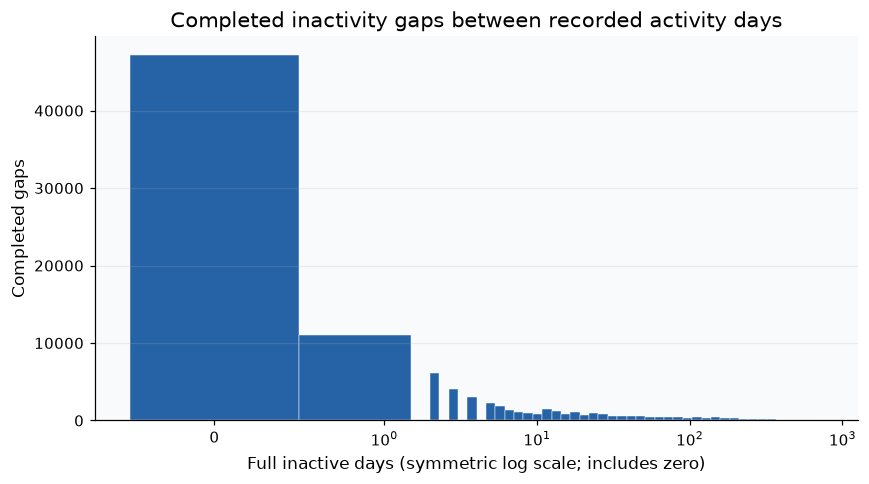

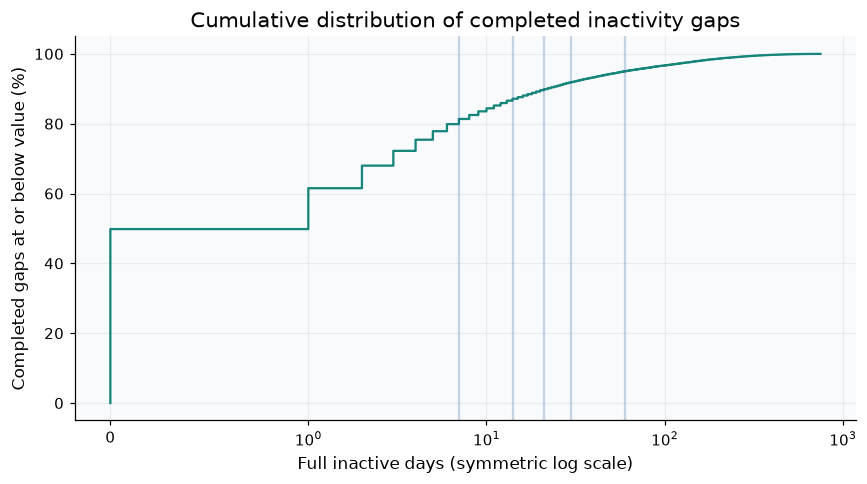

In [6]:
ordered = daily.sort_values(['UserID', 'Date']).copy()
ordered['previous_date'] = ordered.groupby('UserID').Date.shift()
ordered['interval_days'] = (ordered.Date - ordered.previous_date).dt.days
gaps = ordered.loc[ordered.previous_date.notna(),
                   ['UserID', 'previous_date', 'Date', 'interval_days']].copy()
gaps['inactive_days'] = (gaps.interval_days - 1).astype('int64')
assert len(gaps) == len(daily) - len(players)
assert gaps.inactive_days.ge(0).all()
gap_quantiles = gaps[['interval_days', 'inactive_days']].quantile([.5, .75, .9, .95, .99, 1]).T
gap_quantiles.columns = ['Median', 'P75', 'P90', 'P95', 'P99', 'Maximum']
display(gap_quantiles)
player_median_gaps = gaps.groupby('UserID').inactive_days.median()
print('Player-level median inactivity gap distribution (equal player weight):')
display(player_median_gaps.quantile([.5, .75, .9, .95]).rename('days').to_frame())
bet_days = ordered.loc[ordered.Bets.gt(0)].copy()
bet_days['interval_days'] = bet_days.groupby('UserID').Date.diff().dt.days
bet_inactivity = bet_days.interval_days.dropna() - 1
print('Positive-bet-day sensitivity: pooled full inactive days')
display(bet_inactivity.quantile([.5, .75, .9, .95]).rename('days').to_frame())
fig, ax = plt.subplots(figsize=(8, 4.5))
edges = np.unique(np.r_[-.5, .5, np.geomspace(1.5, gaps.inactive_days.max()+.5, 45)])
ax.hist(gaps.inactive_days, bins=edges, color=BLUE, edgecolor='white', linewidth=.3)
ax.set_xscale('symlog', linthresh=1)
ax.set(title='Completed inactivity gaps between recorded activity days',
       xlabel='Full inactive days (symmetric log scale; includes zero)', ylabel='Completed gaps')
ax.grid(axis='y', alpha=.2)
fig.tight_layout()
save_show(fig, 'inactivity_gap_distribution.png')
fig, ax = plt.subplots(figsize=(8, 4.5))
v = np.sort(gaps.inactive_days.to_numpy())
ax.step(v, np.arange(1, len(v)+1)/len(v)*100, color=TEAL)
ax.set_xscale('symlog', linthresh=1)
for threshold in [7, 14, 21, 30, 60]: ax.axvline(threshold, alpha=.25, color=BLUE)
ax.set(title='Cumulative distribution of completed inactivity gaps',
       xlabel='Full inactive days (symmetric log scale)', ylabel='Completed gaps at or below value (%)')
ax.grid(alpha=.2)
fig.tight_layout()
save_show(fig, 'inactivity_gap_ecdf.png')
q = gaps.inactive_days.quantile([.5, .75, .9, .95])
qi = gaps.interval_days.quantile([.5, .75, .9, .95])
section_notes['gaps'] = f"""**Interpretation.** Across {len(gaps):,} completed gaps, full inactive
days have median/P75/P90/P95 of **{q.iloc[0]:g}/{q.iloc[1]:g}/{q.iloc[2]:g}/{q.iloc[3]:g} days**.
Under the alternative inter-activity interval convention these are
{qi.iloc[0]:g}/{qi.iloc[1]:g}/{qi.iloc[2]:g}/{qi.iloc[3]:g} days.
{gaps.inactive_days.eq(0).mean()*100:.1f}% of completed gaps are consecutive-day returns.
The median of players' own median inactivity gaps is {player_median_gaps.median():g} days;
this differs in weighting from the pooled result. Positive-bet-day sensitivity gives
median/P75/P90/P95 of {'/'.join(f'{x:g}' for x in bet_inactivity.quantile([.5,.75,.9,.95]))} days.
Completed-gap quantiles describe returners and do not estimate final departure times.
The long-gap return analysis below is necessary before interpreting a gap as churn."""

**Interpretation.** Across 94,769 completed gaps, full inactive
days have median/P75/P90/P95 of **1/4/22/60 days**.
Under the alternative inter-activity interval convention these are
2/5/23/61 days.
49.8% of completed gaps are consecutive-day returns.
The median of players' own median inactivity gaps is 1.5 days;
this differs in weighting from the pooled result. Positive-bet-day sensitivity gives
median/P75/P90/P95 of 1/4/22/60 days.
Completed-gap quantiles describe returners and do not estimate final departure times.
The long-gap return analysis below is necessary before interpreting a gap as churn.

## 7. Returns after 7, 14, 21, 30, and 60 full inactive days
A spell starts after a recorded day. It reaches threshold **D** at `previous activity + D`
if there is no activity on those D full dates. Thus a completed spell qualifies when
`next date − previous date − 1 >= D`. A terminal spell qualifies only when at least D
inactive days are visible before the study ends. Spells too close to the end to reach D
are excluded, not counted as failures.

Three complementary quantities are shown for each threshold:

1. **Player observed-return share:** distinct players with any qualifying completed gap /
   distinct players with any qualifying completed or terminal spell. A player can both
   return in one spell and remain inactive in a later spell. This is an observed lower
   bound with unequal follow-up, not a prospective churn probability.
2. **Spell observed-return share:** qualifying completed gaps / all qualifying spells,
   including terminal censored spells. Unreturned spells are censored, not known churn.
3. **90-day follow-up return rate:** use only threshold crossings at least 90 days before
   the end; count a return within 90 days **after reaching D**. The denominator is eligible
   spells, with a common follow-up period. Repeated spells from one player are dependent.

All rates are conditional on reaching the threshold and have explicit denominators.
The fixed 90-day horizon is an EDA comparison, **not a chosen prediction window**.
Players who return after 90 follow-up days remain outside that fixed-horizon numerator.

,players_reaching_threshold,players_with_observed_return,player_observed_return_pct,qualifying_spells,completed_return_spells,terminal_censored_spells,spell_observed_return_pct,eligible_90day_spells,returns_within_90days,return_within_90days_pct
inactive_threshold_days,,,,,,,,,,
7,4221,3759,89.055,23037,19069,3968,82.776,21090,14756,69.967
14,4209,3484,82.775,16553,12706,3847,76.759,15125,9013,59.590
21,4197,3303,78.699,13608,9860,3748,72.457,12397,6505,52.472
30,4157,3118,75.006,11416,7768,3648,68.045,10381,4781,46.055
60,4024,2665,66.228,8138,4753,3385,58.405,7383,2574,34.864


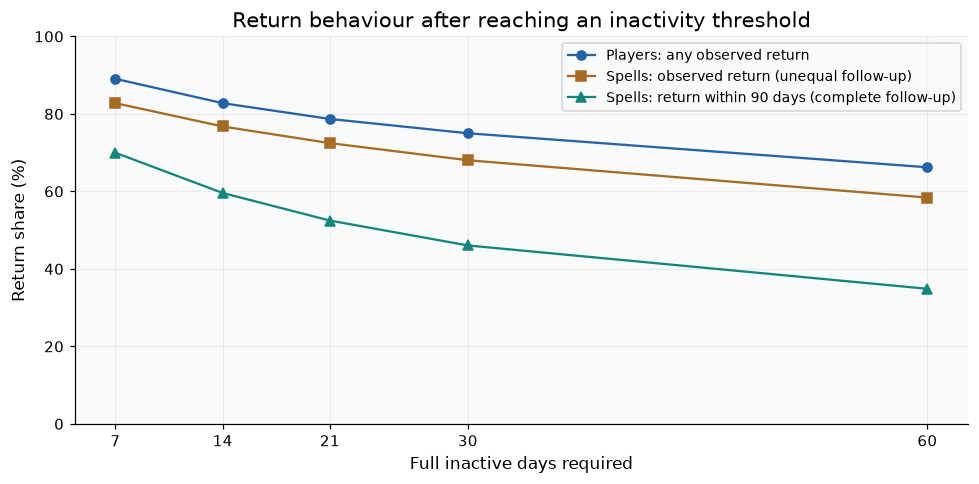

In [7]:
completed = gaps.rename(columns={'previous_date': 'spell_start', 'Date': 'return_date'})[
    ['UserID', 'spell_start', 'return_date', 'inactive_days']]
terminal = players[['UserID', 'last_activity']].rename(columns={'last_activity': 'spell_start'}).copy()
terminal['return_date'] = pd.NaT
terminal['inactive_days'] = (study_end - terminal.spell_start).dt.days
spells = pd.concat([completed, terminal], ignore_index=True)
assert len(spells) == len(daily)
return_rows = []
for threshold in [7, 14, 21, 30, 60]:
    qualifying = spells.loc[spells.inactive_days.ge(threshold)].copy()
    qualifying['crossing_date'] = qualifying.spell_start + pd.Timedelta(days=threshold)
    returned = qualifying.return_date.notna()
    exposed_players = qualifying.UserID.nunique()
    returning_players = qualifying.loc[returned, 'UserID'].nunique()
    eligible = qualifying.loc[qualifying.crossing_date.le(study_end - pd.Timedelta(days=90))]
    returned_within_90 = eligible.return_date.notna() & eligible.return_date.le(
        eligible.crossing_date + pd.Timedelta(days=90))
    return_rows.append({'inactive_threshold_days': threshold,
        'players_reaching_threshold': exposed_players,
        'players_with_observed_return': returning_players,
        'player_observed_return_pct': 100*returning_players/exposed_players,
        'qualifying_spells': len(qualifying), 'completed_return_spells': int(returned.sum()),
        'terminal_censored_spells': int((~returned).sum()),
        'spell_observed_return_pct': 100*returned.mean(),
        'eligible_90day_spells': len(eligible),
        'returns_within_90days': int(returned_within_90.sum()),
        'return_within_90days_pct': 100*returned_within_90.mean()})
return_summary = pd.DataFrame(return_rows).set_index('inactive_threshold_days')
display(return_summary)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(return_summary.index, return_summary.player_observed_return_pct, marker='o',
        label='Players: any observed return', color=BLUE)
ax.plot(return_summary.index, return_summary.spell_observed_return_pct, marker='s',
        label='Spells: observed return (unequal follow-up)', color='#a66b25')
ax.plot(return_summary.index, return_summary.return_within_90days_pct, marker='^',
        label='Spells: return within 90 days (complete follow-up)', color=TEAL)
ax.set(title='Return behaviour after reaching an inactivity threshold',
       xlabel='Full inactive days required', ylabel='Return share (%)', ylim=(0,100),
       xticks=return_summary.index)
ax.legend(fontsize=9)
ax.grid(alpha=.2)
fig.tight_layout()
save_show(fig, 'returns_after_inactivity.png')
rows = ['| Full inactive days | Players returning / exposed | Observed player share | 90-day spell returns / eligible | 90-day return rate |',
        '| --- | --- | --- | --- | --- |']
for threshold, r in return_summary.iterrows():
    rows.append(f'| {threshold} | {r.players_with_observed_return:,.0f} / {r.players_reaching_threshold:,.0f} | '
        f'{r.player_observed_return_pct:.1f}% | {r.returns_within_90days:,.0f} / {r.eligible_90day_spells:,.0f} | '
        f'{r.return_within_90days_pct:.1f}% |')
section_notes['returns'] = '**Interpretation.** Observed results:\n\n' + '\n'.join(rows) + f"""


Even after 60 full inactive days, {return_summary.loc[60, 'players_with_observed_return']:,.0f}
players are observed returning. A long gap therefore does not establish permanent exit.
The 90-day rates answer a different, comparable-horizon question; terminal spells in the
unequal-follow-up measures may still return after data collection stops. Neither rate
should be presented as the probability of never returning."""

**Interpretation.** Observed results:

| Full inactive days | Players returning / exposed | Observed player share | 90-day spell returns / eligible | 90-day return rate |
| --- | --- | --- | --- | --- |
| 7 | 3,759 / 4,221 | 89.1% | 14,756 / 21,090 | 70.0% |
| 14 | 3,484 / 4,209 | 82.8% | 9,013 / 15,125 | 59.6% |
| 21 | 3,303 / 4,197 | 78.7% | 6,505 / 12,397 | 52.5% |
| 30 | 3,118 / 4,157 | 75.0% | 4,781 / 10,381 | 46.1% |
| 60 | 2,665 / 4,024 | 66.2% | 2,574 / 7,383 | 34.9% |


Even after 60 full inactive days, 2,665
players are observed returning. A long gap therefore does not establish permanent exit.
The 90-day rates answer a different, comparable-horizon question; terminal spells in the
unequal-follow-up measures may still return after data collection stops. Neither rate
should be presented as the probability of never returning.

## 8. Implications for future churn and window design
Use the observed gap distribution, long-gap returns, account activation timing, and
cohort trend together. These observations inform a future operational definition;
they do not determine a label in this notebook.

In [8]:
section_notes['implications'] = f"""**Evidence-based implications.**

- Typical activity is intermittent: the median player has {players.active_days.median():.0f}
  recorded days over the full dataset. A short inactivity threshold can identify normal
  pauses as well as disengagement. Compare candidate thresholds against observed returns.
- Completed inactivity P90/P95 are {q.loc[.9]:g}/{q.loc[.95]:g} full days, but these
  exclude terminal spells. Do not infer an exit threshold from completed gaps alone.
- At 30 and 60 full inactive days, the common-follow-up return rates are
  {return_summary.loc[30, 'return_within_90days_pct']:.1f}% and
  {return_summary.loc[60, 'return_within_90days_pct']:.1f}% within a further 90 days.
  Choose an operational inactivity outcome and state its horizon; permanent churn is
  not observable in this finite dataset.
- Later activation and declining/increasing cohort participation must be distinguished
  from individual inactivity. Define eligibility relative to first observed casino play
  and pay-in, and compare behaviour in earlier and later calendar periods.
- Decide whether activity means any recorded transaction or positive Bets. Zero-bet
  accounting days should not silently reset a betting-based inactivity clock; the
  sensitivity results in section 6 quantify the difference in gap percentiles.
- Heavy monetary tails call for medians, robust transformations, and potentially log
  features later. Preserve signed winnings corrections and net winners.
- Future training snapshots must recompute summaries using only the feature window;
  reserve the complete subsequent prediction window and exclude or explicitly handle
  censored outcomes near 2007-02-28. Use temporal evaluation, not full-period aggregates.
- Demographic imbalance and small country groups limit subgroup conclusions. Compare
  label prevalence and performance only after labels are defined, with group sizes shown.

**No churn threshold, feature window, or prediction window has been selected here.**"""
assert {p.name: hashlib.sha256(p.read_bytes()).hexdigest() for p in input_paths} == input_hashes
assert all((FIGURE_DIR / name).stat().st_size > 0 for name in saved_figures)
print(f'Analysis complete: {len(saved_figures)} figures saved in reports/figures/.')
print('Input CSV hashes unchanged; descriptive tables remain in memory.')
display(pd.DataFrame({'saved_figure': saved_figures}))

Analysis complete: 16 figures saved in reports/figures/.
Input CSV hashes unchanged; descriptive tables remain in memory.


,saved_figure
0,active_days_distribution.png
1,total_bets_distribution.png
2,stake_distribution.png
3,winnings_distribution.png
4,net_loss_distribution.png
5,average_stake_per_bet_distribution.png
6,monthly_active_players.png
7,monthly_total_stake.png
8,monthly_total_bets.png
9,active_days_vs_total_stake.png


**Evidence-based implications.**

- Typical activity is intermittent: the median player has 11
  recorded days over the full dataset. A short inactivity threshold can identify normal
  pauses as well as disengagement. Compare candidate thresholds against observed returns.
- Completed inactivity P90/P95 are 22/60 full days, but these
  exclude terminal spells. Do not infer an exit threshold from completed gaps alone.
- At 30 and 60 full inactive days, the common-follow-up return rates are
  46.1% and
  34.9% within a further 90 days.
  Choose an operational inactivity outcome and state its horizon; permanent churn is
  not observable in this finite dataset.
- Later activation and declining/increasing cohort participation must be distinguished
  from individual inactivity. Define eligibility relative to first observed casino play
  and pay-in, and compare behaviour in earlier and later calendar periods.
- Decide whether activity means any recorded transaction or positive Bets. Zero-bet
  accounting days should not silently reset a betting-based inactivity clock; the
  sensitivity results in section 6 quantify the difference in gap percentiles.
- Heavy monetary tails call for medians, robust transformations, and potentially log
  features later. Preserve signed winnings corrections and net winners.
- Future training snapshots must recompute summaries using only the feature window;
  reserve the complete subsequent prediction window and exclude or explicitly handle
  censored outcomes near 2007-02-28. Use temporal evaluation, not full-period aggregates.
- Demographic imbalance and small country groups limit subgroup conclusions. Compare
  label prevalence and performance only after labels are defined, with group sizes shown.

**No churn threshold, feature window, or prediction window has been selected here.**